In [1]:
# This cell imports all required libraries.
# - requests: to download data from the USGS API
# - pandas: for data cleaning and analysis
# - plotly.graph_objects: for interactive plotting
# - calendar: for readable month names
# - StringIO: to read text data as a file
# - os: to handle directories and file output

import requests
import pandas as pd
import plotly.graph_objects as go
import calendar
from io import StringIO
import os


In [2]:
# This cell defines user-configurable parameters.
# Change these values to analyze a different site, parameter, or year.

site_no = "08330000"          # USGS site number (Rio Grande at Albuquerque)
parameter_cd = "00060"        # Discharge parameter (cubic feet per second)
start_date = "2024-01-01"     # Start date (YYYY-MM-DD)
end_date = "2024-12-31"       # End date (YYYY-MM-DD)

In [3]:
# This cell builds the USGS Daily Values (DV) API request
# and downloads the data in RDB (tab-delimited) format.

url = (
    "https://waterservices.usgs.gov/nwis/dv/"
    f"?sites={site_no}"
    f"&parameterCd={parameter_cd}"
    f"&startDT={start_date}"
    f"&endDT={end_date}"
    "&format=rdb"
)

print("Downloading data from USGS...")
response = requests.get(url)
response.raise_for_status()   # Stop execution if the request fails
rdb_text = response.text      # Raw RDB text response


In [4]:
# USGS RDB files contain comment lines starting with '#'.
# This cell removes those lines and reads the remaining data into pandas.

lines = [
    line for line in rdb_text.splitlines()
    if not line.startswith("#") and line.strip()
]

df = pd.read_csv(StringIO("\n".join(lines)), sep="\t")

# Display the first few rows to verify the data loaded correctly
df.head()


,agency_cd,site_no,datetime,99853_00060_00003,99853_00060_00003_cd
0,5s,15s,20d,14n,10s
1,USGS,08330000,2024-01-01,514,A
2,USGS,08330000,2024-01-02,511,A
3,USGS,08330000,2024-01-03,480,A
4,USGS,08330000,2024-01-04,465,A


In [5]:
# USGS discharge columns usually contain the parameter code (00060).
# This logic makes the notebook robust across different datasets.

value_column = next(
    col for col in df.columns
    if "00060" in col or "discharge" in col.lower()
)

# USGS uses either 'datetime' or 'dateTime' depending on the service
date_col = "datetime" if "datetime" in df.columns else "dateTime"

value_column, date_col


('99853_00060_00003', 'datetime')

In [6]:
# Convert discharge values to numeric (invalid entries become NaN)
df[value_column] = pd.to_numeric(df[value_column], errors="coerce")

# Parse dates using the known USGS date format to avoid warnings
df[date_col] = pd.to_datetime(
    df[date_col],
    format="%Y-%m-%d",
    errors="coerce"
)

# Drop rows with missing discharge values or dates
df = df.dropna(subset=[value_column, date_col])

df.head()


,agency_cd,site_no,datetime,99853_00060_00003,99853_00060_00003_cd
1,USGS,08330000,2024-01-01,514.0,A
2,USGS,08330000,2024-01-02,511.0,A
3,USGS,08330000,2024-01-03,480.0,A
4,USGS,08330000,2024-01-04,465.0,A
5,USGS,08330000,2024-01-05,472.0,A


In [7]:
# 1️⃣ Create a 'month' column from the date column
df["month"] = df[date_col].dt.month

# 2️⃣ Group only by months that exist in your data
monthly = df.groupby("month")[value_column].agg(["min", "max", "count"])

# 3️⃣ Print only months present in the dataset
print("Monthly Min / Max Discharge (cfs):")
for m in sorted(monthly.index):
    name = calendar.month_abbr[m]
    print(f"{name}: min = {monthly.loc[m,'min']}, max = {monthly.loc[m,'max']}")


Monthly Min / Max Discharge (cfs):
Jan: min = 374.0, max = 518.0
Feb: min = 429.0, max = 564.0
Mar: min = 441.0, max = 626.0
Apr: min = 482.0, max = 3120.0
May: min = 1160.0, max = 2670.0
Jun: min = 370.0, max = 2080.0
Jul: min = 74.2, max = 871.0
Aug: min = 136.0, max = 561.0
Sep: min = 64.9, max = 787.0
Oct: min = 40.9, max = 548.0
Nov: min = 286.0, max = 897.0
Dec: min = 530.0, max = 1040.0


In [8]:
# This cell creates a standardized daily discharge table
# and saves it as a CSV file for external use.

year = pd.to_datetime(start_date).year

daily_out = pd.DataFrame({
    "agency_cd": "USGS",
    "site_no": site_no,
    "parameter_cd": parameter_cd,
    "Year": df[date_col].dt.year,
    "month_nu": df[date_col].dt.month,
    "day_nu": df[date_col].dt.day,
    "discharge": df[value_column]
})

# Create output directory if it does not exist
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, f"stats_{site_no}_{year}.csv")
daily_out.to_csv(csv_path, index=False)

csv_path


'plots\\stats_08330000_2024.csv'

In [9]:
# Calculate annual minimum and maximum discharge values
overall_min = df[value_column].min()
overall_max = df[value_column].max()

# Find the dates when min and max occurred
min_date = df.loc[df[value_column].idxmin(), date_col]
max_date = df.loc[df[value_column].idxmax(), date_col]

print(f"Annual Min: {overall_min} cfs on {min_date.date()}")
print(f"Annual Max: {overall_max} cfs on {max_date.date()}")


Annual Min: 40.9 cfs on 2024-10-18
Annual Max: 3120.0 cfs on 2024-04-26


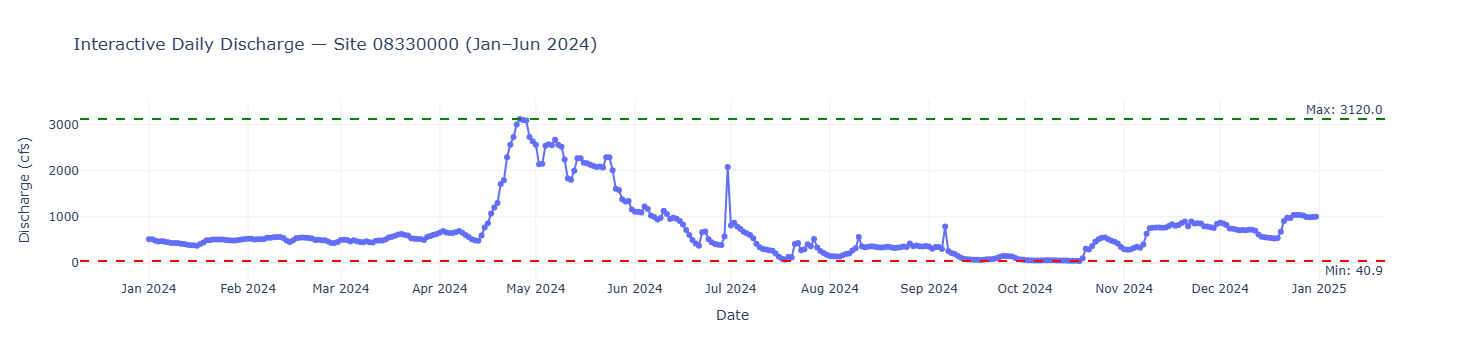

In [10]:
# -------------------------------
# INTERACTIVE PLOT (PLOTLY) — UPDATED
# -------------------------------
fig = go.Figure()

# Main daily discharge line
fig.add_trace(
    go.Scatter(
        x=df[date_col],
        y=df[value_column],
        mode="lines+markers",
        name="Daily Discharge",
        hovertemplate=
        "<b>Date:</b> %{x|%Y-%m-%d}<br>"
        "<b>Discharge:</b> %{y:.2f} cfs<extra></extra>"
    )
)

# Add annual min line
fig.add_hline(
    y=overall_min,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Min: {overall_min}",
    annotation_position="bottom right"
)

# Add annual max line
fig.add_hline(
    y=overall_max,
    line_dash="dash",
    line_color="green",
    annotation_text=f"Max: {overall_max}",
    annotation_position="top right"
)

# Layout settings with month-level ticks for clarity
fig.update_layout(
    title=f"Interactive Daily Discharge — Site {site_no} (Jan–Jun {year})",
    xaxis_title="Date",
    yaxis_title="Discharge (cfs)",
    hovermode="x unified",
    template="plotly_white",
    xaxis=dict(
        dtick="M1",       # one tick per month
        tickformat="%b %Y"  # Jan 2024, Feb 2024, ...
    )
)

# Display interactive figure
fig
